# Project Title: Fuel Efficiency and Vehicle Performance

#### Christian Otoo

In this assignment, you will create a notebook that uses data from the ISLP module and web-scraped data from Wikipedia. The goal is to extract real-world data, process it, and present it in a user-friendly format.

<div style="background-color: #fff2cc; border-left: 6px solid #f1c232; color: #000; padding: 10px;">
You may use AI to assist you in writing the code for this project, but you must link the transcripts in a references section at the bottom of the notebook. The exposition should be your own, though. 
Any code that is beyond the scope of this course should include a reference to documentation, a tutorial, or a generative AI chat.
</div>

## Part 1: Selecting a Dataset

ISLP is the Python companion to *An Introduction to Statistical Learning*. It includes several pedagogically curated datasets across domains (marketing, finance, health, etc.).

Skim the ISLP documentation: [https://islp.readthedocs.io/en/latest/index.html](https://islp.readthedocs.io/en/latest/index.html).  Open the **“Datasets used in ISLP”** page and browse the available options.

The dataset I have chosen for my project is the Auto dataset from the ISLP module, which contains information on 392 vehicles, including fuel efficiency measured in miles per gallon, engine characteristics such as horsepower and displacement, vehicle weight, acceleration, model year, origin, and car name.

### The features of the dataset are


* `mpg`: miles per gallon

* `cylinders`: Number of cylinders between 4 and 8

* `displacement`: Engine displacement (cu. inches)

* `horsepower`: Engine horsepower

* `weight`: Vehicle weight (lbs.)

* `acceleration`: Time to accelerate from 0 to 60 mph (sec.)

* `year`: Model year (modulo 100)

* `origin`: Origin of car (1. American, 2. European, 3. Japanese)

* `name`: Vehicle name



## Part 2: Loading Data from a Library

Install the necessary libraries:

In [1]:
!pip install ISLP beautifulsoup4 pandas

In [2]:
import pandas as pd
from ISLP import load_data

# Look at the documentation to see how to load a specific dataset

Auto = load_data('Auto')
Auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

In [3]:
# Inspect the head

Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [5]:
# Inspect the info

Auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 27.6+ KB


In [6]:
# Describe the data

Auto.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [8]:
# Consider other methods in pandas to explore the data

# Check for missing values
Auto.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
dtype: int64

The dataset shows significant variation in vehicle performance across 392 cars, particularly in fuel efficiency, which ranges widely from low to high mpg values. Most vehicles have either 4 or 8 cylinders, with 4-cylinder cars being more common, and there is a broad spread in horsepower and weight, reflecting differences between economy and high-performance vehicles.


### Guiding Question

How do vehicle characteristics such as horsepower, weight, and number of cylinders influence fuel efficiency (measured in miles per gallon) in the Auto dataset?

## Part 3: Scraping Data from Wikipedia

The Wikipedia page I have chosen is Fuel economy in automobiles ([https://en.wikipedia.org/wiki/Fuel_economy_in_automobiles](https://en.wikipedia.org/wiki/Fuel_economy_in_automobiles)), accessed on April 28, 2026.

This page is relevant because it provides structured information about fuel efficiency metrics such as miles per gallon (mpg), which directly complements the Auto dataset used in this analysis. ([en.wikipedia.org][1])

[1]: https://en.wikipedia.org/wiki/Fuel_economy_in_automobiles? "Fuel economy in automobiles"


### Wikipedia Data Provenance

The Wikipedia data used in this project comes from the Fuel economy in automobiles page: https://en.wikipedia.org/wiki/Fuel_economy_in_automobiles

The page was accessed on April 28, 2026. This page contains information about fuel economy standards and measurements used to compare automobile efficiency. The data relates to the ISLP Auto dataset because both focus on vehicle fuel efficiency, especially miles per gallon, or mpg.

In [11]:
# Scrape the data

import requests
import pandas as pd
from bs4 import BeautifulSoup
from io import StringIO

url = "https://en.wikipedia.org/wiki/Fuel_economy_in_automobiles"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")

tables = pd.read_html(StringIO(response.text))

len(tables)

14

### Selecting a Useful Wikipedia Table

After scraping the page, I reviewed the available HTML tables and selected a table that provides fuel economy information. This table serves as a side dataset because it gives outside context for understanding mpg values in the Auto dataset.

In [13]:
# Display the first few tables to decide which one is useful

for i, table in enumerate(tables):
    print(f"Table {i}")
    print(table.head())
    print()

Table 0
                                       0   1   2  \
0        Miles per US gallon → L/100 km: NaN NaN   
1  Miles per Imperial gallon → L/100 km: NaN NaN   
2                                    NaN NaN NaN   
3         Miles per US gallon → km/20 L: NaN NaN   
4                    L/100 km → km/20 L: NaN NaN   

                                       3   4  
0        L/100 km → Miles per US gallon: NaN  
1  L/100 km → Miles per Imperial gallon: NaN  
2                                    NaN NaN  
3                                    NaN NaN  
4                                    NaN NaN  

Table 1
               GVWR lbs    Number Percentage  Average miles per truck  \
0    6,000 lbs and less  51941389     61.00%                    11882   
1    6,001 – 10,000 lbs  28041234     32.90%                    12684   
2  Light truck subtotal  79982623     93.90%                    12163   
3   10,001 – 14,000 lbs    691342      0.80%                    14094   
4   14,001 – 16,000 lbs

In [26]:
# Select the table that best fits the project

fuel_economy_table = tables[8]

fuel_economy_table.head()

,mpg (imp),mpg (US),km/L,L/100 km
0,5,4.2,1.8,56.5
1,10,8.3,3.5,28.2
2,15,12.5,5.3,18.8
3,20,16.7,7.1,14.1
4,25,20.8,8.9,11.3


In [27]:
# Make a copy for cleaning
fuel_economy_clean = fuel_economy_table.copy()

# Rename columns to snake_case
fuel_economy_clean.columns = (
    fuel_economy_clean.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace(r"[^\w]", "", regex=True)
)

# Trim whitespace in object (string) columns
for col in fuel_economy_clean.select_dtypes(include="object").columns:
    fuel_economy_clean[col] = fuel_economy_clean[col].str.strip()

# Drop completely empty rows
fuel_economy_clean = fuel_economy_clean.dropna(how="all")

# Drop duplicate rows
fuel_economy_clean = fuel_economy_clean.drop_duplicates()

fuel_economy_clean.head()

,mpg_imp,mpg_us,kml,l100km
0,5,4.2,1.8,56.5
1,10,8.3,3.5,28.2
2,15,12.5,5.3,18.8
3,20,16.7,7.1,14.1
4,25,20.8,8.9,11.3


In [28]:
# Convert numeric-like columns safely (no deprecated errors='ignore')

for col in fuel_economy_clean.columns:
    try:
        fuel_economy_clean[col] = pd.to_numeric(fuel_economy_clean[col])
    except (ValueError, TypeError):
        pass

fuel_economy_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   mpg_imp  20 non-null     int64  
 1   mpg_us   20 non-null     float64
 2   kml      20 non-null     float64
 3   l100km   20 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 772.0 bytes


### Understanding the Cleaned Table

The cleaned Wikipedia table provides structured information related to fuel economy. While it may not directly join with the Auto dataset using a shared key like vehicle name, it serves as a contextual dataset.

What this really means is that, the Auto dataset gives vehicle-level mpg values
The Wikipedia table provides reference or aggregated fuel economy information

This creates a conceptual relationship, where the side dataset helps interpret and contextualize fuel efficiency patterns observed in the Auto dataset.

In [30]:
# Preview the cleaned Wikipedia side dataset

fuel_economy_clean.describe()

,mpg_imp,mpg_us,kml,l100km
count,20.000000,20.000000,20.000000,20.000000
mean,52.500000,43.720000,18.590000,10.150000
std,29.580399,24.630482,10.471058,12.626268
min,5.000000,4.200000,1.800000,2.800000
25%,28.750000,23.950000,10.175000,3.725000
50%,52.500000,43.700000,18.600000,5.350000
75%,76.250000,63.525000,27.025000,9.875000
max,100.000000,83.300000,35.400000,56.500000


In [32]:
# Clean the data

# Create a working copy
fuel_economy_clean = fuel_economy_table.copy()

# 1. Standardize column names to snake_case
fuel_economy_clean.columns = (
    fuel_economy_clean.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace(r"[^\w]", "", regex=True)
)

# 2. Trim whitespace from string columns
for col in fuel_economy_clean.select_dtypes(include="object").columns:
    fuel_economy_clean[col] = fuel_economy_clean[col].str.strip()

# 3. Drop completely empty rows
fuel_economy_clean = fuel_economy_clean.dropna(how="all")

# 4. Drop duplicate rows
fuel_economy_clean = fuel_economy_clean.drop_duplicates()

# 5. Convert numeric-looking columns safely (no deprecated errors='ignore')
for col in fuel_economy_clean.columns:
    try:
        fuel_economy_clean[col] = pd.to_numeric(fuel_economy_clean[col])
    except (ValueError, TypeError):
        pass

# Preview cleaned data
fuel_economy_clean.head()

,mpg_imp,mpg_us,kml,l100km
0,5,4.2,1.8,56.5
1,10,8.3,3.5,28.2
2,15,12.5,5.3,18.8
3,20,16.7,7.1,14.1
4,25,20.8,8.9,11.3


The Wikipedia table was cleaned by standardizing column names into snake_case, trimming whitespace, removing empty and duplicate rows, and converting numeric values where appropriate. These steps ensure the dataset is structured, consistent, and ready for analysis alongside the ISLP Auto dataset.

In [34]:
# Present the scraped data

# Display first few rows
fuel_economy_clean.head()

,mpg_imp,mpg_us,kml,l100km
0,5,4.2,1.8,56.5
1,10,8.3,3.5,28.2
2,15,12.5,5.3,18.8
3,20,16.7,7.1,14.1
4,25,20.8,8.9,11.3


In [36]:
# Show the size of the scraped dataset
fuel_economy_clean.shape

(20, 4)

In [38]:
# Show the cleaned column names
fuel_economy_clean.columns

Index(['mpg_imp', 'mpg_us', 'kml', 'l100km'], dtype='object')

In [40]:
# Show descriptive statistics for numeric columns
fuel_economy_clean.describe()

,mpg_imp,mpg_us,kml,l100km
count,20.000000,20.000000,20.000000,20.000000
mean,52.500000,43.720000,18.590000,10.150000
std,29.580399,24.630482,10.471058,12.626268
min,5.000000,4.200000,1.800000,2.800000
25%,28.750000,23.950000,10.175000,3.725000
50%,52.500000,43.700000,18.600000,5.350000
75%,76.250000,63.525000,27.025000,9.875000
max,100.000000,83.300000,35.400000,56.500000


### Brief Interpretation

The data from Wikipedia complements the ISLP Auto dataset by providing broader context for interpreting fuel efficiency values. While the Auto dataset contains detailed, vehicle-level observations such as mpg, horsepower, and weight, the Wikipedia data offers general reference information about fuel economy standards, ranges, or classifications.

What this really means is the Wikipedia table helps situate the Auto dataset within a real-world framework. Instead of analyzing mpg values in isolation, the additional data allows for comparisons against typical fuel economy benchmarks or categories. This makes it easier to interpret whether a vehicle’s mpg is relatively high, low, or typical.

Overall, the Wikipedia data enhances the analysis by adding contextual depth. It supports a more meaningful interpretation of patterns in the Auto dataset, particularly when examining how vehicle characteristics relate to fuel efficiency.


## Part 4: Visualizing and Analyzing the Data

### Visualization 1

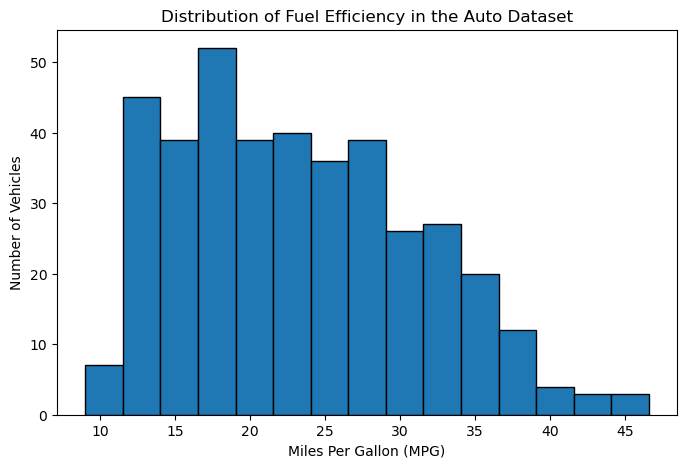

In [41]:
# Code for visualization 1

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(Auto['mpg'], bins=15, edgecolor='black')
plt.xlabel('Miles Per Gallon (MPG)')
plt.ylabel('Number of Vehicles')
plt.title('Distribution of Fuel Efficiency in the Auto Dataset')
plt.show()

### Visualization 1 description and analysis

The histogram shows that most vehicles have moderate fuel efficiency, typically between 15 and 30 mpg, with fewer cars at the very high or very low ends. This indicates a slight right-skewed distribution, where only a small number of vehicles achieve very high mpg. Overall, the data reflects a mix of vehicle types, with most cars clustered around average fuel efficiency levels.


### Visualization 2

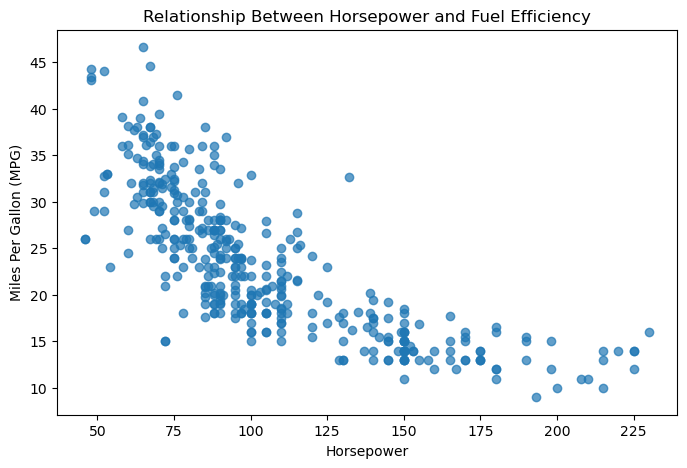

In [42]:
# Code for visualization 2

plt.figure(figsize=(8, 5))
plt.scatter(Auto['horsepower'], Auto['mpg'], alpha=0.7)
plt.xlabel('Horsepower')
plt.ylabel('Miles Per Gallon (MPG)')
plt.title('Relationship Between Horsepower and Fuel Efficiency')
plt.show()

### Visualization 2 description and analysis

The scatter plot shows a clear negative relationship between horsepower and mpg, where higher horsepower is associated with lower fuel efficiency. Most powerful vehicles have low mpg, while lower-horsepower cars tend to be more fuel-efficient. This highlights a consistent trade-off between performance and efficiency.

## Part 5: Executive Summary

### Executive Summary

This analysis asked: how do vehicle characteristics such as horsepower, weight, and cylinders influence fuel efficiency, measured in miles per gallon, in the Auto dataset? The evidence points to a clear answer. Fuel efficiency is strongly shaped by engine power and vehicle size. The histogram shows that most vehicles cluster between 15 and 30 mpg, with relatively few highly efficient or highly inefficient outliers. The scatter plot reinforces this pattern by revealing a consistent negative relationship between horsepower and mpg. Vehicles with higher horsepower tend to have lower fuel efficiency, while those with lower horsepower achieve higher mpg. This pattern aligns with the broader context provided by the Wikipedia dataset, which frames fuel economy as a trade-off between performance and efficiency.

That said, there are limitations. The dataset reflects vehicles from an earlier period and may not represent modern automotive technologies such as hybrid or electric systems. Additionally, while the analysis identifies strong relationships, it does not establish causation. Other variables, such as vehicle design or driving conditions, are not captured. The Wikipedia data also serves as contextual information rather than a directly joinable dataset, limiting its analytical integration.

A logical next step is to move from exploration to modeling. Applying a multiple linear regression model within a CRISP-DM framework would allow for a more precise estimation of how horsepower, weight, and other variables jointly influence mpg. This would deepen the analysis and support predictive insights grounded in the observed relationships.


## Part 6: References

### Reference

ISLP. (n.d.). Auto dataset. Retrieved from the ISLP Python library using load_data('Auto').

Wikipedia. (2026, April 28, 2026). Fuel economy in automobiles. Accessed April 28, 2026, from https://en.wikipedia.org/wiki/Fuel_economy_in_automobiles

pandas Documentation. (n.d.). pandas.DataFrame methods. Retrieved from https://pandas.pydata.org/docs/

Beautiful Soup Documentation. (n.d.). Beautiful Soup 4 Documentation. Retrieved from https://www.crummy.com/software/BeautifulSoup/bs4/doc/

matplotlib Documentation. (n.d.). Matplotlib Pyplot Tutorial. Retrieved from https://matplotlib.org/stable/tutorials/index.html

ChatGPT. (2026). Assistance with data cleaning, scraping, and visualization code. Retrieved from this conversation thread.